# Dimensionnement du fonds de défaut Cover-2

Ce notebook met en œuvre la chaîne complète de dimensionnement du fonds de défaut d'une chambre de compensation selon le standard Cover-2.

L'objectif est de mesurer, sous un même scénario de stress, les pertes de marché qui restent à la charge de la CCP après épuisement de la marge initiale de chaque membre. Pour le membre $i$ et le scénario $s$, cette perte résiduelle est la SLOIM :

$$\mathrm{SLOIM}_i(s)=\max\left(L_i(s)-IM_i,0\right).$$

Le besoin Cover-2 d'un scénario est la somme des deux plus grandes SLOIM simultanées. Le fonds de défaut brut est donc dimensionné par :

$$DF_{\mathrm{Cover2}}=
\max_s\left[
\mathrm{SLOIM}_{(1)}(s)+\mathrm{SLOIM}_{(2)}(s)
\right].$$

L'analyse en composantes principales constitue le moteur de construction des scénarios de stress. Elle permet de résumer les principaux mouvements historiques de la courbe ZC et de produire deux familles complémentaires :

1. des scénarios historiques correspondant aux dates extrêmes des composantes principales ;
2. des scénarios hypothétiques construits à partir des queues de distribution de leurs scores.

La chaîne étudiée est ainsi :

$$\text{courbe ZC}
\rightarrow \text{scénarios de stress ACP}
\rightarrow \text{PnL par membre}
\rightarrow \text{pertes}
\rightarrow \text{marge initiale}
\rightarrow \text{SLOIM}
\rightarrow \text{Cover-2}.$$

Le notebook applique cette démarche à quatre portefeuilles obligataires afin d'identifier le scénario contraignant, les deux membres qui déterminent le besoin et le montant du fonds de défaut.



## 1. Préparation de l'environnement


In [2]:
import Pkg

project_root = pwd()
if basename(project_root) == "notebooks"
    project_root = dirname(project_root)
end

Pkg.activate(project_root)
Pkg.instantiate()

using DataFrames
using Dates
using LinearAlgebra
using Plots
using Statistics
using DefaultFundJulia


  Activating project at `~/Desktop/Stage_QuantFactory_Julia`


## 2. Paramètres du calcul


In [3]:
config = ModelConfig(
    HP=5,
    t0="2025-05-30",
    alpha=0.99,
    nominal=100.0,
)

DataFrame(
    parametre=["HP", "t0", "alpha", "nominal"],
    valeur=[config.HP, config.t0, config.alpha, config.nominal],
)


Row,parametre,valeur
,String,Any
1,HP,5
2,t0,2025-05-30
3,alpha,0.99
4,nominal,100.0


## 3. Chargement de la courbe ZC

Le notebook cherche d'abord `ZeroCouponCurve.csv` dans le repo Julia. Si le fichier n'est pas encore copié, il cherche aussi dans les anciens repos de travail.


In [4]:
zc_candidates = [
    joinpath(project_root, "data", "raw", "ZeroCouponCurve.csv"),
    joinpath(dirname(project_root), "Stage_QuantFactory", "IM_pipeline.", "IM_pipeline", "data", "raw", "ZeroCouponCurve.csv"),
    joinpath(dirname(project_root), "Stage_addons", "IM_pipeline.", "IM_pipeline", "data", "raw", "ZeroCouponCurve.csv"),
]

existing_zc_paths = filter(isfile, zc_candidates)
isempty(existing_zc_paths) && error("ZeroCouponCurve.csv introuvable.")

zc_path = first(existing_zc_paths)


"/home/jellilm/Desktop/Stage_QuantFactory/IM_pipeline./IM_pipeline/data/raw/ZeroCouponCurve.csv"

In [5]:
zc_curve = load_zero_coupon_curve(zc_path)

DataFrame(
    objet=["courbe ZC"],
    chemin=[zc_path],
    premiere_date=[first(zc_curve.dates)],
    derniere_date=[last(zc_curve.dates)],
    lignes=[length(zc_curve.dates)],
    piliers=[length(zc_curve.pillars)],
)


Row,objet,chemin,premiere_date,derniere_date,lignes,piliers
,String,String,Date,Date,Int64,Int64
1,courbe ZC,/home/jellilm/Desktop/Stage_QuantFactory/IM_pipeline./IM_pipeline/data/raw/ZeroCouponCurve.csv,2012-03-27,2025-05-30,3439,33


In [6]:
DataFrame(
    pilier=zc_curve.pillars,
    valeur_t0=row_at(zc_curve, config.t0),
)


Row,pilier,valeur_t0
,Float64,Float64
1,0.25,0.00603953
2,0.5,0.00827397
3,1.0,0.00309975
4,2.0,0.0328934
5,3.0,0.0329128
6,4.0,0.028528
7,5.0,0.0241431
8,6.0,0.0232301
9,7.0,0.0254308


## 4. Calcul des returns Litterman

On garde une seule définition de return pour la suite : l'approximation de Litterman sur zéro-coupon.

Pour un pilier de maturité $T_k$, on part de la variation de taux ZC sur l'horizon `HP` :

$$\Delta y_{t,k}=y_{t,k}-y_{t-HP,k}.$$

Le return de prix ZC est ensuite approximé par :

$$R^{Lit}_{t,k}\approx -T_k\,\Delta y_{t,k}.$$

Intuition : si le taux monte, le prix du zéro-coupon baisse. Plus la maturité $T_k$ est longue, plus l'impact est fort.

Cette matrice `litterman_returns` sera la base utilisée pour l'ACP et la construction des scénarios de stress.


In [7]:
litterman_returns = compute_litterman_zero_returns(zc_curve; HP=config.HP)

# Version uniquement pour lecture des ordres de grandeur : return exprimé en pourcentage.
litterman_returns_pct = CurveMatrix(
    litterman_returns.dates,
    litterman_returns.pillars,
    litterman_returns.values .* 100.0,
)

DataFrame(
    objet=["returns Litterman -T * Delta y"],
    debut=[first(litterman_returns.dates)],
    fin=[last(litterman_returns.dates)],
    lignes=[length(litterman_returns.dates)],
    piliers=[length(litterman_returns.pillars)],
)


Row,objet,debut,fin,lignes,piliers
,String,Date,Date,Int64,Int64
1,returns Litterman -T * Delta y,2012-04-03,2025-05-30,3434,33


## 5. Aperçu statistique des returns Litterman

Ce tableau résume l'amplitude des returns par pilier. Il sert à repérer les maturités les plus volatiles avant de passer à l'ACP.


In [8]:
return_summary = DataFrame(
    pilier=litterman_returns.pillars,
    moyenne_pct=vec(mean(litterman_returns_pct.values; dims=1)),
    volatilite_pct=vec(std(litterman_returns_pct.values; dims=1)),
    min_pct=vec(minimum(litterman_returns_pct.values; dims=1)),
    max_pct=vec(maximum(litterman_returns_pct.values; dims=1)),
)

first(return_summary, 12)


Row,pilier,moyenne_pct,volatilite_pct,min_pct,max_pct
,Float64,Float64,Float64,Float64,Float64
1,0.25,0.0017388,0.202573,-1.30313,2.54479
2,0.5,0.00329649,0.370309,-2.54556,4.95907
3,1.0,0.00736018,0.710188,-5.4569,9.39605
4,2.0,0.00586776,1.17376,-8.72551,16.7038
5,3.0,0.0085068,1.49093,-11.6316,21.9232
6,4.0,0.0135071,1.60975,-13.5665,25.0543
7,5.0,0.0195897,1.64621,-14.5302,26.097
8,6.0,0.0236836,1.61883,-14.5229,25.0514
9,7.0,0.0247087,1.44914,-13.5444,21.9175


## 6. ACP sur les returns Litterman

On applique l'ACP sur la matrice des returns :

$$R^{Lit}_{t,k}\approx -T_k\left(y_{t,k}-y_{t-HP,k}\right).$$

L'étape d'ACP peut s'écrire sous la forme :

$$X = U S V^T.$$

Ici, `fit_pca_stress` centre la matrice des returns, calcule la matrice de covariance, puis récupère les trois premiers vecteurs propres.


In [9]:
pca_model = fit_pca_stress(litterman_returns; n_components=3)

total_variance = sum(var(litterman_returns.values; dims=1))

pca_summary = DataFrame(
    facteur=["PC1", "PC2", "PC3"],
    eigenvalue=pca_model.eigenvalues,
    volatilite_facteur=sqrt.(pca_model.eigenvalues),
    part_variance=pca_model.eigenvalues ./ total_variance,
    part_cumulee=cumsum(pca_model.eigenvalues) ./ total_variance,
)

pca_summary


Row,facteur,eigenvalue,volatilite_facteur,part_variance,part_cumulee
,String,Float64,Float64,Float64,Float64
1,PC1,0.0358936,0.189456,0.888421,0.888421
2,PC2,0.00147106,0.0383543,0.0364108,0.924831
3,PC3,0.00106341,0.0326099,0.0263209,0.951152


## 7. Eigenvectors / loadings sur les piliers

Les colonnes de la matrice $V$ sont les vecteurs propres. Dans notre code, ce sont les `loadings` :

```julia
pca_model.loadings[:, k]
```

Chaque vecteur donne la forme du choc associé à une composante principale sur les piliers de la courbe.


In [10]:
loadings_table = DataFrame(pilier=pca_model.pillars)
for k in 1:3
    loadings_table[!, Symbol("PC$(k)")] = pca_model.loadings[:, k]
end

first(loadings_table, 12)


Row,pilier,PC1,PC2,PC3
,Float64,Float64,Float64,Float64
1,0.25,-0.000173757,-0.0411991,-0.00293192
2,0.5,-0.000544251,-0.0803352,-0.00573384
3,1.0,-0.000620291,-0.153541,-0.011771
4,2.0,-0.00101771,-0.275191,-0.0175359
5,3.0,-0.00136451,-0.362303,-0.0185607
6,4.0,-0.0012036,-0.408156,-0.0201277
7,5.0,-0.00073482,-0.416552,-0.0193848
8,6.0,0.000376838,-0.40037,-0.0141637
9,7.0,0.00144999,-0.359176,-0.00819194


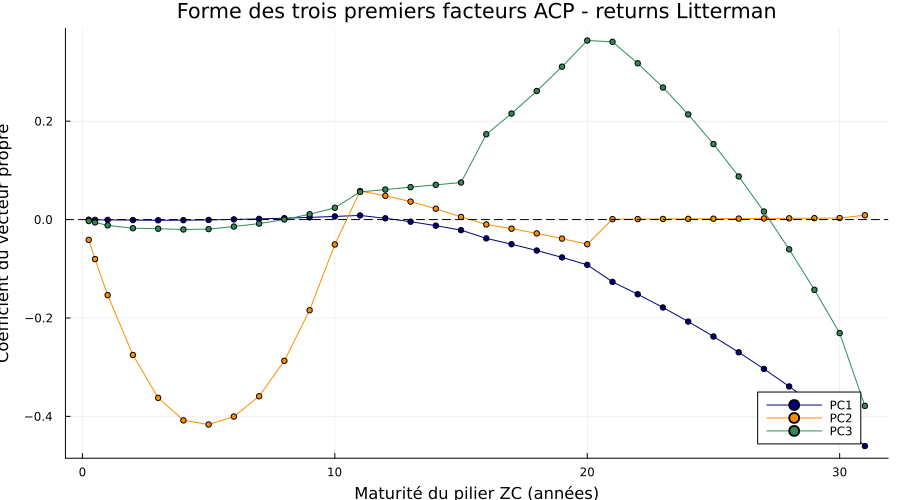

In [11]:
pca_factor_plot = plot(
    xlabel="Maturité du pilier ZC (années)",
    ylabel="Coefficient du vecteur propre",
    title="Forme des trois premiers facteurs ACP - returns Litterman",
    legend=:bottomright,
    linewidth=3,
    size=(900, 500),
)

factor_labels = ["PC1", "PC2", "PC3"]
factor_colors = [:navy, :darkorange, :seagreen]

for k in 1:3
    plot!(
        pca_factor_plot,
        pca_model.pillars,
        pca_model.loadings[:, k];
        label=factor_labels[k],
        color=factor_colors[k],
        marker=:circle,
        markersize=3,
    )
end

hline!(pca_factor_plot, [0.0]; color=:black, linestyle=:dash, label=false)
pca_factor_plot


## 8. Séries temporelles des composantes principales

On écrit :

$$PCs(t)=X(t)\cdot V^T.$$

Dans notre implémentation, les séries temporelles des composantes principales sont stockées dans :

```julia
pca_model.scores
```

Chaque ligne correspond à une date, et chaque colonne à une composante principale.


In [12]:
pc_scores = DataFrame(date=pca_model.dates)
for k in 1:3
    pc_scores[!, Symbol("PC$(k)")] = pca_model.scores[:, k]
end

first(pc_scores, 10)


Row,date,PC1,PC2,PC3
,Date,Float64,Float64,Float64
1,2012-04-03,-0.0817642,-0.000443467,0.0138486
2,2012-04-04,-0.0818125,-0.000438343,0.013848
3,2012-04-05,-0.0818073,-0.000437378,0.0138458
4,2012-04-06,0.0212953,-0.00404636,0.00367823
5,2012-04-09,0.0215018,-0.0040502,0.00365265
6,2012-04-10,0.0214916,-0.0040487,0.00365189
7,2012-04-11,0.0215361,-0.0040515,0.00364942
8,2012-04-12,0.0214982,-0.0040467,0.00364779
9,2012-04-13,0.0214886,-0.00404527,0.00364705


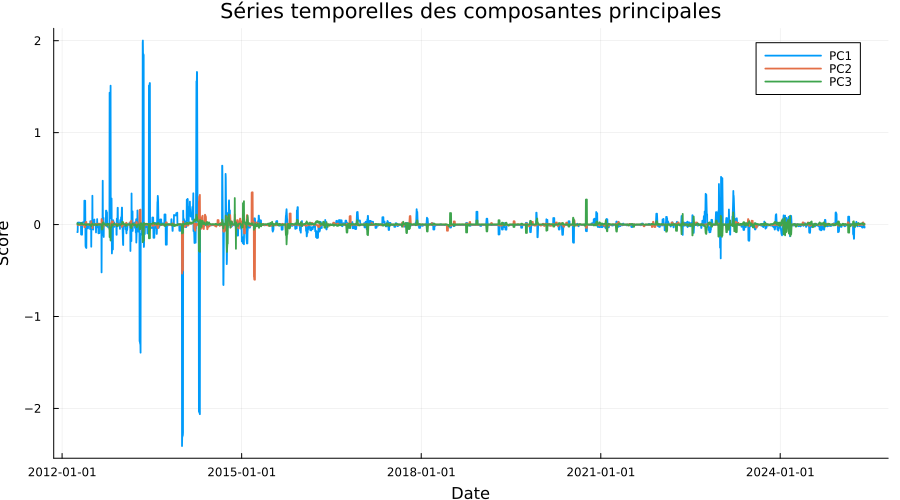

In [13]:
pc_scores_plot = plot(
    pc_scores.date,
    pc_scores.PC1;
    label="PC1",
    linewidth=1.8,
    xlabel="Date",
    ylabel="Score",
    title="Séries temporelles des composantes principales",
    size=(900, 500),
    grid=true,
)
plot!(pc_scores.date, pc_scores.PC2; label="PC2", linewidth=1.8)
plot!(pc_scores.date, pc_scores.PC3; label="PC3", linewidth=1.8)
pc_scores_plot


## 9. Historical Scenarios Extraction

On extrait les scénarios historiques à partir des dates extrêmes des composantes principales.

Pour chaque composante $PC_i$, on sélectionne deux dates :

$$Date_i^- = \arg\min_t PC_i(t), \qquad Date_i^+ = \arg\max_t PC_i(t).$$

Ces dates correspondent aux observations historiques où le facteur ACP a eu son mouvement le plus extrême. Ensuite, on récupère le vecteur complet de returns Litterman observé à ces dates sur tous les piliers ZC.

Point important : si deux composantes donnent la même date extrême, on ne garde la date qu'une seule fois.


In [14]:
function extract_pca_historical_extremes(model::PCAStressModel)
    rows = NamedTuple[]

    for component in 1:length(model.eigenvalues)
        scores = model.scores[:, component]

        low_index = argmin(scores)
        high_index = argmax(scores)

        push!(rows, (
            component="PC$(component)",
            side="min",
            date=model.dates[low_index],
            score=scores[low_index],
            row_index=low_index,
        ))

        push!(rows, (
            component="PC$(component)",
            side="max",
            date=model.dates[high_index],
            score=scores[high_index],
            row_index=high_index,
        ))
    end

    return DataFrame(rows)
end

pca_historical_extremes = extract_pca_historical_extremes(pca_model)
pca_historical_extremes


Row,component,side,date,score,row_index
,String,String,Date,Float64,Int64
1,PC1,min,2014-01-02,-2.40944,458
2,PC1,max,2013-05-08,2.00235,287
3,PC2,min,2015-03-23,-0.599844,775
4,PC2,max,2015-03-06,0.351087,764
5,PC3,min,2014-10-03,-0.297692,654
6,PC3,max,2014-11-20,0.288603,688


## 10. Construction de la matrice des scénarios historiques

Le tableau précédent identifie les dates extrêmes dans l'espace ACP. On reconstruit maintenant la matrice de scénarios historiques en reprenant, pour chaque date retenue, la ligne correspondante de `litterman_returns`.

La sortie `historical_pca_scenarios` contient donc :

- une ligne par scénario historique retenu ;
- une colonne par pilier ZC ;
- des valeurs exprimées en returns Litterman, cohérentes avec l'ACP.


In [15]:
selected_indices = unique(pca_historical_extremes.row_index)

label_by_index = Dict{Int,String}()
for row in eachrow(pca_historical_extremes)
    label = "HIST_$(row.component)_$(row.side)_$(row.date)"
    if haskey(label_by_index, row.row_index)
        label_by_index[row.row_index] *= "__$(row.component)_$(row.side)"
    else
        label_by_index[row.row_index] = label
    end
end

historical_pca_scenarios = ScenarioMatrix(
    [label_by_index[i] for i in selected_indices],
    litterman_returns.pillars,
    litterman_returns.values[selected_indices, :],
)

historical_pca_summary = DataFrame(
    scenario=historical_pca_scenarios.labels,
    date=litterman_returns.dates[selected_indices],
)

historical_pca_summary


Row,scenario,date
,String,Date
1,HIST_PC1_min_2014-01-02,2014-01-02
2,HIST_PC1_max_2013-05-08,2013-05-08
3,HIST_PC2_min_2015-03-23,2015-03-23
4,HIST_PC2_max_2015-03-06,2015-03-06
5,HIST_PC3_min_2014-10-03,2014-10-03
6,HIST_PC3_max_2014-11-20,2014-11-20


In [16]:
n_preview_pillars = min(8, length(historical_pca_scenarios.pillars))
preview_pillars = historical_pca_scenarios.pillars[1:n_preview_pillars]
preview_names = Symbol.("T_" .* replace.(string.(preview_pillars), "." => "p") .* "Y")

historical_pca_matrix_preview = DataFrame(
    historical_pca_scenarios.values[:, 1:n_preview_pillars],
    preview_names,
)
insertcols!(historical_pca_matrix_preview, 1, :scenario => historical_pca_scenarios.labels)

historical_pca_matrix_preview


Row,scenario,T_0p25Y,T_0p5Y,T_1p0Y,T_2p0Y,T_3p0Y,T_4p0Y,T_5p0Y,T_6p0Y
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,HIST_PC1_min_2014-01-02,0.0220799,0.0430292,0.0815363,0.144984,0.190342,0.217612,0.226793,0.217885
2,HIST_PC1_max_2013-05-08,0.0033263,0.00648527,0.0123013,0.0219255,0.0288727,0.0331428,0.0347358,0.0336517
3,HIST_PC2_min_2015-03-23,0.0254479,0.0495907,0.0939605,0.167038,0.219232,0.250543,0.26097,0.250514
4,HIST_PC2_max_2015-03-06,-0.0130313,-0.0254556,-0.0484833,-0.0872551,-0.116316,-0.135665,-0.145302,-0.145229
5,HIST_PC3_min_2014-10-03,-0.00262311,-0.00512264,-0.00975093,-0.0175245,-0.0233206,-0.0271394,-0.0289808,-0.0288448
6,HIST_PC3_max_2014-11-20,-0.00450908,-0.0088074,-0.0167717,-0.0301711,-0.0401982,-0.046853,-0.0501355,-0.0500456


## 11. Hypothetical Scenarios

Les scénarios hypothétiques sont construits à partir des **quantiles des composantes principales**.

Pour chaque composante principale $PC_i$, on fixe un niveau de confiance $\alpha$, puis :

$$n_{obs}=round\left((1-\alpha)T\right),$$

où $T$ est le nombre total d'observations historiques.

On trie ensuite les valeurs historiques de $PC_i(t)$ et on calcule deux moyennes de queue :

$$PC_{down,i}=\frac{1}{n_{obs}}\sum_{j=1}^{n_{obs}}PC_i^{sort}(j),$$

$$PC_{up,i}=\frac{1}{n_{obs}}\sum_{j=T-n_{obs}+1}^{T}PC_i^{sort}(j).$$

Ces deux valeurs représentent les mouvements extrêmes bas et haut du facteur $i$.


In [17]:
hypothetical_alpha = 0.99

pc_tail_quantiles = compute_pc_tail_quantiles(
    pca_model;
    alpha=hypothetical_alpha,
)
n_obs = first(pc_tail_quantiles.n_obs)

pc_tail_quantiles


Row,component,component_name,side,alpha,n_obs,pc_tail_mean
,Int64,String,String,Float64,Int64,Float64
1,1,PC1,down,0.99,34,-1.02175
2,1,PC1,up,0.99,34,1.13763
3,2,PC2,down,0.99,34,-0.213275
4,2,PC2,up,0.99,34,0.175964
5,3,PC3,down,0.99,34,-0.185259
6,3,PC3,up,0.99,34,0.152784


## 12. Génération des scénarios hypothétiques

Une fois les queues $PC_{down,i}$ et $PC_{up,i}$ calculées, on génère les scénarios en multipliant le vecteur propre par la valeur extrême de la composante :

$$Scenario_{k,i,+}=v_{k,i}\times PC_{up,i},$$

$$Scenario_{k,i,-}=v_{k,i}\times PC_{down,i}.$$

Ici :

- $k$ désigne le pilier ZC ;
- $i$ désigne la composante principale ;
- $v_{k,i}$ est le coefficient du vecteur propre $i$ sur le pilier $k$.

Avec 3 composantes principales, on obtient donc 6 scénarios hypothétiques : down/up de PC1, down/up de PC2 et down/up de PC3.


In [18]:
hypothetical_pca_scenarios = build_tail_hypothetical_scenarios(
    pca_model;
    alpha=hypothetical_alpha,
)

DataFrame(
    objet=["scénarios hypothétiques ACP par queues"],
    alpha=[hypothetical_alpha],
    n_obs=[n_obs],
    lignes=[length(hypothetical_pca_scenarios.labels)],
    piliers=[length(hypothetical_pca_scenarios.pillars)],
)


Row,objet,alpha,n_obs,lignes,piliers
,String,Float64,Int64,Int64,Int64
1,scénarios hypothétiques ACP par queues,0.99,34,6,33


In [19]:
n_preview_pillars = min(8, length(hypothetical_pca_scenarios.pillars))
preview_pillars = hypothetical_pca_scenarios.pillars[1:n_preview_pillars]
preview_names = Symbol.("T_" .* replace.(string.(preview_pillars), "." => "p") .* "Y")

hypothetical_pca_matrix_preview = DataFrame(
    hypothetical_pca_scenarios.values[:, 1:n_preview_pillars],
    preview_names,
)
insertcols!(
    hypothetical_pca_matrix_preview,
    1,
    :scenario => hypothetical_pca_scenarios.labels,
)

hypothetical_pca_matrix_preview


Row,scenario,T_0p25Y,T_0p5Y,T_1p0Y,T_2p0Y,T_3p0Y,T_4p0Y,T_5p0Y,T_6p0Y
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,ACP_HYPO_P_MOV_DOWN_alpha99,0.000177536,0.000556087,0.00063378,0.00103984,0.00139419,0.00122978,0.0007508,-0.000385033
2,ACP_HYPO_P_MOV_UP_alpha99,-0.000197671,-0.000619156,-0.000705661,-0.00115778,-0.00155231,-0.00136926,-0.000835953,0.000428702
3,ACP_HYPO_S_MOV_DOWN_alpha99,0.00878672,0.0171335,0.0327463,0.0586913,0.0772701,0.0870494,0.08884,0.0853889
4,ACP_HYPO_S_MOV_UP_alpha99,-0.00724954,-0.0141361,-0.0270176,-0.0484237,-0.0637522,-0.0718206,-0.073298,-0.0704506
5,ACP_HYPO_C_MOV_DOWN_alpha99,0.000543164,0.00106224,0.00218068,0.00324869,0.00343853,0.00372883,0.0035912,0.00262395
6,ACP_HYPO_C_MOV_UP_alpha99,-0.000447951,-0.000876041,-0.00179843,-0.00267922,-0.00283578,-0.0030752,-0.00296169,-0.00216399


## 13. Récapitulatif des scénarios construits

On concatène les scénarios historiques ACP et les scénarios hypothétiques ACP dans une seule matrice.

Le tableau final affiche une ligne par scénario, avec :

- `ROW` : numéro de ligne du scénario dans la matrice finale ;
- `famille` : historique ACP ou hypothétique ACP ;
- `nombre_scenarios` : nombre total de scénarios dans cette famille ;
- `scenario` : nom du scénario ;
- toutes les maturités de la courbe ZC.


In [20]:
all_stress_scenarios = concat_scenarios(
    historical_pca_scenarios,
    hypothetical_pca_scenarios,
)

historical_count = length(historical_pca_scenarios.labels)
hypothetical_count = length(hypothetical_pca_scenarios.labels)

scenario_families = vcat(
    fill("historique ACP", historical_count),
    fill("hypothétique ACP par queues", hypothetical_count),
)

scenario_family_counts = vcat(
    fill(historical_count, historical_count),
    fill(hypothetical_count, hypothetical_count),
)

maturity_names = Symbol.(
    "T_" .* replace.(string.(all_stress_scenarios.pillars), "." => "p") .* "Y"
)

scenario_matrix_df = DataFrame(
    all_stress_scenarios.values,
    maturity_names,
)

insertcols!(scenario_matrix_df, 1, :scenario => all_stress_scenarios.labels)
insertcols!(scenario_matrix_df, 1, :nombre_scenarios => scenario_family_counts)
insertcols!(scenario_matrix_df, 1, :famille => scenario_families)
insertcols!(scenario_matrix_df, 1, :ROW => 1:length(all_stress_scenarios.labels))

scenario_matrix_df


Row,ROW,famille,nombre_scenarios,scenario,T_0p25Y,T_0p5Y,T_1p0Y,T_2p0Y,T_3p0Y,T_4p0Y,T_5p0Y,T_6p0Y,T_7p0Y,T_8p0Y,T_9p0Y,T_10p0Y,T_11p0Y,T_12p0Y,T_13p0Y,T_14p0Y,T_15p0Y,T_16p0Y,T_17p0Y,T_18p0Y,T_19p0Y,T_20p0Y,T_21p0Y,T_22p0Y,T_23p0Y,T_24p0Y,T_25p0Y,T_26p0Y,T_27p0Y,T_28p0Y,T_29p0Y,T_30p0Y,T_31p0Y
,Int64,String,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,historique ACP,6,HIST_PC1_min_2014-01-02,0.0220799,0.0430292,0.0815363,0.144984,0.190342,0.217612,0.226793,0.217885,0.190888,0.145803,0.0826285,0.00136524,-0.0979868,-0.0798453,-0.0571956,-0.0300377,0.00162851,0.0378029,0.0784855,0.123676,0.173375,0.227583,0.286298,0.349522,0.417254,0.489494,0.566243,0.647499,0.733264,0.823538,0.918319,1.01761,1.12141
2,2,historique ACP,6,HIST_PC1_max_2013-05-08,0.0033263,0.00648527,0.0123013,0.0219255,0.0288727,0.0331428,0.0347358,0.0336517,0.0298907,0.0234525,0.0143373,0.00254499,-0.0119244,-0.0290708,-0.0488942,-0.0713948,-0.0965724,-0.124427,-0.154959,-0.188168,-0.224053,-0.262616,-0.303856,-0.347773,-0.394367,-0.443639,-0.495587,-0.550212,-0.607514,-0.667494,-0.73015,-0.795484,-0.863494
3,3,historique ACP,6,HIST_PC2_min_2015-03-23,0.0254479,0.0495907,0.0939605,0.167038,0.219232,0.250543,0.26097,0.250514,0.219175,0.166953,0.0938477,-0.000141082,0.000809682,0.000421662,-4.3296e-5,-0.000585192,-0.00120403,-0.00143303,-0.00168063,-0.00194681,-0.00223159,-0.00253496,-0.0216233,-0.0218675,-0.0220403,-0.0221416,-0.0221716,-0.0221301,-0.0220172,-0.021833,-0.0215773,-0.0212502,-0.0208517
4,4,historique ACP,6,HIST_PC2_max_2015-03-06,-0.0130313,-0.0254556,-0.0484833,-0.0872551,-0.116316,-0.135665,-0.145302,-0.145229,-0.135444,-0.115947,-0.0867396,-0.0478204,0.000810119,0.000829303,0.000839409,0.000840438,0.000832389,0.000864649,0.000894004,0.000920456,0.000944003,0.000964646,0.00120967,0.00124146,0.00127091,0.001298,0.00132275,0.00134516,0.00136521,0.00138292,0.00139828,0.0014113,0.00142197
5,5,historique ACP,6,HIST_PC3_min_2014-10-03,-0.00262311,-0.00512264,-0.00975093,-0.0175245,-0.0233206,-0.0271394,-0.0289808,-0.0288448,-0.0267314,-0.0226407,-0.0165725,-0.00852698,0.00149594,0.0230249,0.0481194,0.0767793,0.109005,0.0734443,0.0325304,-0.0137369,-0.0653577,-0.122332,-0.0980477,-0.0708682,-0.0407934,-0.00782334,0.0280421,0.0668028,0.108459,0.15301,0.200457,0.250799,0.304036
6,6,historique ACP,6,HIST_PC3_max_2014-11-20,-0.00450908,-0.0088074,-0.0167717,-0.0301711,-0.0401982,-0.046853,-0.0501355,-0.0500456,-0.0465835,-0.039749,-0.0295423,-0.0159632,0.000988214,0.00864434,0.0175615,0.0277397,0.039179,0.0503335,0.0625559,0.0758461,0.090204,0.10563,0.0933469,0.0793912,0.0637627,0.0464614,0.0274873,0.00684035,-0.0154794,-0.0394719,-0.0651372,-0.0924753,-0.121486
7,7,hypothétique ACP par queues,6,ACP_HYPO_P_MOV_DOWN_alpha99,0.000177536,0.000556087,0.00063378,0.00103984,0.00139419,0.00122978,0.0007508,-0.000385033,-0.00148152,-0.00287296,-0.00455935,-0.00654069,-0.00860654,-0.00265832,0.00441167,0.0126034,0.021917,0.0390834,0.0511169,0.0642787,0.0785689,0.0939874,0.129411,0.155108,0.18258,0.211828,0.242852,0.275652,0.310228,0.346579,0.384706,0.424609,0.470366
8,8,hypothétique ACP par queues,6,ACP_HYPO_P_MOV_UP_alpha99,-0.000197671,-0.000619156,-0.000705661,-0.00115778,-0.00155231,-0.00136926,-0.000835953,0.000428702,0.00164955,0.0031988,0.00507646,0.00728251,0.00958267,0.00295982,-0.00491203,-0.0140329,-0.0244027,-0.0435161,-0.0569144,-0.071569,-0.0874799,-0.104647,-0.144089,-0.1727,-0.203288,-0.235853,-0.270396,-0.306916,-0.345413,-0.385887,-0.428338,-0.472767,-0.523713
9,9,hypothétique ACP par queues,6,ACP_HYPO_S_MOV_DOWN_alpha99,0.00878672,0.0171335,0.0327463,0.0586913,0.0772701,0.0870494,0.08884,0.0853889,0.0766031,0.061241,0.0393025,0.0107877,-0.0123389,-0.0103238,-0.00778584,-0.00472509,-0.00114153,0.00210666,0.00395004,

## 14. Portefeuilles par membre compensateur

On définit un portefeuille obligataire par membre compensateur. Chaque position contient les informations nécessaires au moteur de pricing : maturité résiduelle, coupon, nominal, fréquence de coupon et quantité.

Convention utilisée :

- `quantity > 0` : position longue sur l'obligation ;
- `quantity < 0` : position courte sur l'obligation.

Ces portefeuilles servent uniquement à transformer les scénarios de courbe ZC en PnL stressés.


In [21]:
member_names = ["Membre_A", "Membre_B", "Membre_C", "Membre_D"]

portfolio_by_member = Dict(
    "Membre_A" => [
        Dict(:name => "MA 2029 5.45", :maturity => 4.47, :coupon_rate => 0.0545, :nominal => 100.0, :frequency => 1, :quantity => 145_000.0),
        Dict(:name => "MA 2032 2.40", :maturity => 7.33, :coupon_rate => 0.0240, :nominal => 100.0, :frequency => 1, :quantity => 95_000.0),
        Dict(:name => "MA 2034 5.85", :maturity => 9.12, :coupon_rate => 0.0585, :nominal => 100.0, :frequency => 1, :quantity => -55_000.0),
        Dict(:name => "MA 2055 4.90", :maturity => 30.01, :coupon_rate => 0.0490, :nominal => 100.0, :frequency => 1, :quantity => 22_000.0),
    ],
    "Membre_B" => [
        Dict(:name => "MA 2026 2.70", :maturity => 0.92, :coupon_rate => 0.0270, :nominal => 100.0, :frequency => 1, :quantity => 210_000.0),
        Dict(:name => "MA 2029 5.60", :maturity => 4.16, :coupon_rate => 0.0560, :nominal => 100.0, :frequency => 1, :quantity => -80_000.0),
        Dict(:name => "MA 2051 3.45", :maturity => 26.02, :coupon_rate => 0.0345, :nominal => 100.0, :frequency => 1, :quantity => 48_000.0),
        Dict(:name => "MA 2055 4.50", :maturity => 30.19, :coupon_rate => 0.0450, :nominal => 100.0, :frequency => 1, :quantity => 35_000.0),
    ],
    "Membre_C" => [
        Dict(:name => "MA 2029 5.45", :maturity => 4.47, :coupon_rate => 0.0545, :nominal => 100.0, :frequency => 1, :quantity => -115_000.0),
        Dict(:name => "MA 2034 5.85", :maturity => 9.12, :coupon_rate => 0.0585, :nominal => 100.0, :frequency => 1, :quantity => 135_000.0),
        Dict(:name => "MA 2032 2.40", :maturity => 7.33, :coupon_rate => 0.0240, :nominal => 100.0, :frequency => 1, :quantity => 45_000.0),
        Dict(:name => "MA 2051 3.45", :maturity => 26.02, :coupon_rate => 0.0345, :nominal => 100.0, :frequency => 1, :quantity => -25_000.0),
    ],
    "Membre_D" => [
        Dict(:name => "MA 2026 2.70", :maturity => 0.92, :coupon_rate => 0.0270, :nominal => 100.0, :frequency => 1, :quantity => -160_000.0),
        Dict(:name => "MA 2029 5.60", :maturity => 4.16, :coupon_rate => 0.0560, :nominal => 100.0, :frequency => 1, :quantity => 65_000.0),
        Dict(:name => "MA 2034 5.85", :maturity => 9.12, :coupon_rate => 0.0585, :nominal => 100.0, :frequency => 1, :quantity => 70_000.0),
        Dict(:name => "MA 2055 4.90", :maturity => 30.01, :coupon_rate => 0.0490, :nominal => 100.0, :frequency => 1, :quantity => -18_000.0),
    ],
)

portfolio_rows = NamedTuple[]
for member in member_names
    for (position_id, position) in enumerate(portfolio_by_member[member])
        push!(portfolio_rows, (
            member=member,
            position_id=position_id,
            instrument=position[:name],
            maturity=position[:maturity],
            coupon_rate=position[:coupon_rate],
            quantity=position[:quantity],
        ))
    end
end

portfolio_df = DataFrame(portfolio_rows)
portfolio_df


Row,member,position_id,instrument,maturity,coupon_rate,quantity
,String,Int64,String,Float64,Float64,Float64
1,Membre_A,1,MA 2029 5.45,4.47,0.0545,145000.0
2,Membre_A,2,MA 2032 2.40,7.33,0.024,95000.0
3,Membre_A,3,MA 2034 5.85,9.12,0.0585,-55000.0
4,Membre_A,4,MA 2055 4.90,30.01,0.049,22000.0
5,Membre_B,1,MA 2026 2.70,0.92,0.027,210000.0
6,Membre_B,2,MA 2029 5.60,4.16,0.056,-80000.0
7,Membre_B,3,MA 2051 3.45,26.02,0.0345,48000.0
8,Membre_B,4,MA 2055 4.50,30.19,0.045,35000.0
9,Membre_C,1,MA 2029 5.45,4.47,0.0545,-115000.0


## 15. Valeur initiale des portefeuilles

Pour calculer un PnL, il faut d'abord une valeur de référence à la date d'évaluation $t_0$.

On construit donc la courbe de prix zéro-coupon à partir de la courbe de taux ZC, puis on valorise chaque portefeuille membre avec cette courbe.

La valeur initiale est :

$$V_0 = V(t_0).$$


In [22]:
zc_price_curve = build_zero_coupon_price_matrix(zc_curve; nominal=config.nominal)
current_zc_prices = row_at(zc_price_curve, config.t0)

zc_price_curve.pillars == all_stress_scenarios.pillars ||
    error("Les piliers des scénarios ne correspondent pas aux piliers de la courbe ZC.")

initial_values_by_member = [
    compute_portfolio_initial_value(
        current_zc_prices,
        all_stress_scenarios.pillars,
        portfolio_by_member[member];
        zc_nominal=config.nominal,
    )
    for member in member_names
]

initial_value_df = DataFrame(
    member=member_names,
    initial_value=initial_values_by_member,
)

initial_value_df


Row,member,initial_value
,String,Float64
1,Membre_A,2.18833e7
2,Membre_B,2.11063e7
3,Membre_C,6.17754e6
4,Membre_D,-2.17964e6


## 16. Calcul des PnL stressés

Pour chaque scénario $s$, le moteur applique le choc aux prix ZC :

$$P^{(s)}(t_0,T_k)=P(t_0,T_k)\left(1+R^{(s)}(T_k)\right).$$

Puis il revalorise le portefeuille sous cette courbe stressée :

$$V^{(s)} = V\left(P^{(s)}\right).$$

Le PnL stressé est alors :

$$PnL^{(s)} = V^{(s)} - V_0.$$

Un PnL négatif correspond à une perte pour le membre.


In [23]:
pnl_by_member = hcat([
    compute_portfolio_pnl_under_scenarios(
        current_zc_prices,
        all_stress_scenarios,
        portfolio_by_member[member];
        zc_nominal=config.nominal,
    )
    for member in member_names
]...)

scenario_families_for_pnl = vcat(
    fill("historique ACP", length(historical_pca_scenarios.labels)),
    fill("hypothétique ACP par queues", length(hypothetical_pca_scenarios.labels)),
)

pnl_by_scenario_df = DataFrame(pnl_by_member, Symbol.(member_names))
insertcols!(pnl_by_scenario_df, 1, :scenario => all_stress_scenarios.labels)
insertcols!(pnl_by_scenario_df, 1, :famille => scenario_families_for_pnl)
insertcols!(pnl_by_scenario_df, 1, :ROW => 1:length(all_stress_scenarios.labels))

pnl_by_scenario_df


Row,ROW,famille,scenario,Membre_A,Membre_B,Membre_C,Membre_D
,Int64,String,String,Float64,Float64,Float64,Float64
1,1,historique ACP,HIST_PC1_min_2014-01-02,5.52111e6,3.23768e6,-9.55515e5,2.20456e5
2,2,historique ACP,HIST_PC1_max_2013-05-08,-2.14321e5,-2.63094e6,6.56618e5,9.0987e5
3,3,historique ACP,HIST_PC2_min_2015-03-23,5.11819e6,1.47466e5,-2.52862e5,1.25757e6
4,4,historique ACP,HIST_PC2_max_2015-03-06,-2.79408e6,-1.04958e5,-3.42014e5,-9.27841e5
5,5,historique ACP,HIST_PC3_min_2014-10-03,-3.29722e5,4.78626e5,-1.28839e5,-3.67402e5
6,6,historique ACP,HIST_PC3_max_2014-11-20,-1.00644e6,-39770.7,-1.48916e5,-2.83442e5
7,7,hypothétique ACP par queues,ACP_HYPO_P_MOV_DOWN_alpha99,476302.0,1.3203e6,-3.91934e5,-3.99695e5
8,8,hypothétique ACP par queues,ACP_HYPO_P_MOV_UP_alpha99,-5.30323e5,-1.47004e6,4.36386e5,4.45028e5
9,9,hypothétique ACP par queues,ACP_HYPO_S_MOV_DOWN_alpha99,1.75478e6,85088.6,-3836.62,4.68703e5


## 17. Lecture des PnL par membre

Le tableau suivant résume l'effet des scénarios sur chaque membre :

- `worst_pnl` : PnL le plus défavorable ;
- `worst_scenario` : scénario responsable du pire PnL ;
- `best_pnl` : PnL le plus favorable ;
- `average_pnl` : PnL moyen sur les scénarios ;
- `loss_scenarios` : nombre de scénarios où le PnL est négatif.


In [24]:
worst_indices = [argmin(pnl_by_member[:, j]) for j in 1:length(member_names)]
best_indices = [argmax(pnl_by_member[:, j]) for j in 1:length(member_names)]

pnl_summary_by_member = DataFrame(
    member=member_names,
    initial_value=initial_values_by_member,
    worst_pnl=[pnl_by_member[worst_indices[j], j] for j in 1:length(member_names)],
    worst_scenario=[all_stress_scenarios.labels[worst_indices[j]] for j in 1:length(member_names)],
    best_pnl=[pnl_by_member[best_indices[j], j] for j in 1:length(member_names)],
    best_scenario=[all_stress_scenarios.labels[best_indices[j]] for j in 1:length(member_names)],
    average_pnl=vec(mean(pnl_by_member; dims=1)),
    loss_scenarios=vec(sum(pnl_by_member .< 0.0; dims=1)),
)

pnl_summary_by_member


Row,member,initial_value,worst_pnl,worst_scenario,best_pnl,best_scenario,average_pnl,loss_scenarios
,String,Float64,Float64,String,Float64,String,Float64,Int64
1,Membre_A,2.18833e7,-2.79408e6,HIST_PC2_max_2015-03-06,5.52111e6,HIST_PC1_min_2014-01-02,546873.0,7
2,Membre_B,2.11063e7,-2.63094e6,HIST_PC1_max_2013-05-08,3.23768e6,HIST_PC1_min_2014-01-02,78925.9,6
3,Membre_C,6.17754e6,-9.55515e5,HIST_PC1_min_2014-01-02,6.56618e5,HIST_PC1_max_2013-05-08,-94188.2,8
4,Membre_D,-2.17964e6,-9.27841e5,HIST_PC2_max_2015-03-06,1.25757e6,HIST_PC2_min_2015-03-23,77745.6,6


## 18. Conversion en pertes stressées

Pour la SLOIM, on ne retient que les pertes. On convertit donc les PnL en pertes positives :

$$Loss^{(s)}=\max\left(-PnL^{(s)},0\right).$$

Ce tableau prépare directement l'étape suivante : comparer ces pertes stressées aux marges initiales des membres.


In [25]:
stress_losses_by_member = losses_from_pnl(pnl_by_member)

stress_losses_df = DataFrame(stress_losses_by_member, Symbol.(member_names))
insertcols!(stress_losses_df, 1, :scenario => all_stress_scenarios.labels)
insertcols!(stress_losses_df, 1, :famille => scenario_families_for_pnl)
insertcols!(stress_losses_df, 1, :ROW => 1:length(all_stress_scenarios.labels))

stress_losses_df


Row,ROW,famille,scenario,Membre_A,Membre_B,Membre_C,Membre_D
,Int64,String,String,Float64,Float64,Float64,Float64
1,1,historique ACP,HIST_PC1_min_2014-01-02,0.0,0.0,9.55515e5,0.0
2,2,historique ACP,HIST_PC1_max_2013-05-08,2.14321e5,2.63094e6,0.0,0.0
3,3,historique ACP,HIST_PC2_min_2015-03-23,0.0,0.0,2.52862e5,0.0
4,4,historique ACP,HIST_PC2_max_2015-03-06,2.79408e6,1.04958e5,3.42014e5,9.27841e5
5,5,historique ACP,HIST_PC3_min_2014-10-03,3.29722e5,0.0,1.28839e5,3.67402e5
6,6,historique ACP,HIST_PC3_max_2014-11-20,1.00644e6,39770.7,1.48916e5,2.83442e5
7,7,hypothétique ACP par queues,ACP_HYPO_P_MOV_DOWN_alpha99,0.0,0.0,3.91934e5,3.99695e5
8,8,hypothétique ACP par queues,ACP_HYPO_P_MOV_UP_alpha99,5.30323e5,1.47004e6,0.0,0.0
9,9,hypothétique ACP par queues,ACP_HYPO_S_MOV_DOWN_alpha99,0.0,0.0,3836.62,0.0


## 19. Calcul de la marge initiale par membre

La marge initiale existe déjà dans l'ancien pipeline `Stage_QuantFactory`. La formule utilisée est :

$$ES_{hybrid} = w_{FHS} ES_{FHS} + w_{stress} ES_{stress}$$

puis :

$$IM = \max\left(ES_{FHS}, ES_{hybrid}\right).$$

Dans cette section, on reprend cette logique pour chaque membre :

- construction des scénarios FHS scalés à partir des returns de prix ZC ;
- construction des scénarios de stress historiques bruts ;
- calcul du PnL du portefeuille membre sous chaque bloc ;
- calcul de $ES_{FHS}$, $ES_{stress}$ puis de l'IM hybride avec plancher.

Cette IM sert ensuite de première ligne de couverture dans le calcul de la SLOIM.


In [ ]:
im_returns = compute_historical_returns(zc_price_curve; HP=config.HP)
im_volatility = compute_ewma_volatility(im_returns; lambda_ewma=config.lambda_ewma)

im_fhs_scenarios = build_scaled_scenarios(
    im_returns,
    im_volatility;
    t0=config.t0,
    LP=config.LP,
)

im_stress_scenarios = build_unscaled_scenarios(
    im_returns;
    stress_start=config.stress_start,
    stress_end=config.stress_end,
)

pnl_fhs_by_member = hcat([
    compute_portfolio_pnl_under_scenarios(
        current_zc_prices,
        im_fhs_scenarios,
        portfolio_by_member[member];
        zc_nominal=config.nominal,
    )
    for member in member_names
]...)

pnl_stress_im_by_member = hcat([
    compute_portfolio_pnl_under_scenarios(
        current_zc_prices,
        im_stress_scenarios,
        portfolio_by_member[member];
        zc_nominal=config.nominal,
    )
    for member in member_names
]...)

es_fhs_by_member = [
    compute_es_from_pnl(pnl_fhs_by_member[:, j]; alpha=config.alpha)
    for j in 1:length(member_names)
]

es_stress_by_member = [
    compute_es_from_pnl(pnl_stress_im_by_member[:, j]; alpha=config.alpha)
    for j in 1:length(member_names)
]

es_hybrid_by_member = config.FHS_w .* es_fhs_by_member .+ config.Stress_w .* es_stress_by_member

initial_margin_by_member = [
    compute_initial_margin(
        es_fhs_by_member[j],
        es_stress_by_member[j];
        fhs_w=config.FHS_w,
        stress_w=config.Stress_w,
    )
    for j in 1:length(member_names)
]

initial_margin_df = DataFrame(
    member=member_names,
    ES_FHS=es_fhs_by_member,
    ES_stress=es_stress_by_member,
    ES_hybrid=es_hybrid_by_member,
    initial_margin=initial_margin_by_member,
    n_fhs=fill(length(im_fhs_scenarios.labels), length(member_names)),
    n_stress=fill(length(im_stress_scenarios.labels), length(member_names)),
)

initial_margin_df


## 20. Calcul de la SLOIM

Pour chaque scénario et chaque membre, on compare la perte stressée à la marge initiale du membre.

- si la perte est inférieure à l'IM, la SLOIM est nulle ;
- si la perte dépasse l'IM, la SLOIM correspond à la partie non couverte.

La matrice obtenue a la même dimension que la matrice de PnL : une ligne par scénario et une colonne par membre.


In [ ]:
sloim_by_member = compute_sloim(stress_losses_by_member, initial_margin_by_member)

sloim_df = DataFrame(sloim_by_member, Symbol.(member_names))
insertcols!(sloim_df, 1, :scenario => all_stress_scenarios.labels)
insertcols!(sloim_df, 1, :famille => scenario_families_for_pnl)
insertcols!(sloim_df, 1, :ROW => 1:length(all_stress_scenarios.labels))

sloim_df


In [ ]:
sloim_summary_by_member = DataFrame(
    member=member_names,
    initial_margin=initial_margin_by_member,
    worst_stress_loss=vec(maximum(stress_losses_by_member; dims=1)),
    worst_sloim=vec(maximum(sloim_by_member; dims=1)),
    sloim_scenarios=vec(sum(sloim_by_member .> 0.0; dims=1)),
)

sloim_summary_by_member


## 21. Dimensionnement du fonds de défaut Cover-2

Pour chaque scénario, on classe les SLOIM des membres par ordre décroissant. Le besoin Cover-2 du scénario est la somme des deux plus grandes SLOIM :

$$Cover2^{(s)} = SLOIM_{(1)}^{(s)} + SLOIM_{(2)}^{(s)}.$$

Le montant du fonds de défaut est ensuite le maximum de cette quantité sur tous les scénarios :

$$DF = \max_s Cover2^{(s)}.$$


In [ ]:
cover2_by_scenario = compute_cover2_by_scenario(
    sloim_by_member,
    all_stress_scenarios.labels,
    member_names,
)
insertcols!(cover2_by_scenario, 1, :famille => scenario_families_for_pnl)

cover2_ranked = sort(cover2_by_scenario, :cover2_requirement; rev=true)
cover2_ranked


In [ ]:
binding_cover2 = first(cover2_ranked, 1)
default_fund_cover2 = binding_cover2.cover2_requirement[1]

cover2_final_summary = DataFrame(
    metric=[
        "Montant du fonds de défaut Cover-2",
        "Scénario contraignant",
        "Famille du scénario",
        "Premier membre contributeur au besoin",
        "Deuxième membre contributeur au besoin",
    ],
    value=Any[
        default_fund_cover2,
        binding_cover2.scenario[1],
        binding_cover2.famille[1],
        binding_cover2.first_member[1],
        binding_cover2.second_member[1],
    ],
)

cover2_final_summary


## 22. Conclusion

Le notebook aboutit à une chaîne complète et cohérente de dimensionnement du fonds de défaut Cover-2.

Les trois premières composantes principales concentrent environ **95,12 %** de la variance des returns de courbe. Elles permettent de construire un jeu de stress compact mais interprétable, composé de **six scénarios historiques extrêmes** et de **six scénarios hypothétiques par queues**. Ces douze scénarios sont ensuite appliqués aux quatre portefeuilles pour obtenir les PnL et les pertes stressées de chaque membre.

La marge initiale est calculée séparément à partir de l'Expected Shortfall FHS et de l'Expected Shortfall de stress. La SLOIM isole alors uniquement la fraction de perte qui n'est pas absorbée par cette marge :

$$\mathrm{SLOIM}_i(s)=\max\left(-\mathrm{PnL}_i(s)-IM_i,0\right).$$

Sur l'échantillon et les portefeuilles actuels, le scénario contraignant est :

$$\texttt{HIST\_PC2\_max\_2015\text{-}03\text{-}06},$$

et le besoin brut de fonds de défaut Cover-2 est d'environ :

$$\boxed{DF_{\mathrm{Cover2}}\approx 2{,}91\ \text{millions}}.$$

Ce montant ne correspond pas à l'addition des pires pertes individuelles observées dans des scénarios différents. Il couvre les deux plus grandes pertes résiduelles **simultanées sous un même scénario**, ce qui constitue le principe essentiel du Cover-2.

Le résultat doit enfin être lu comme celui d'un prototype quantitatif : il dépend des portefeuilles, de l'historique disponible, du calibrage des queues et de l'ensemble de stress retenu. L'ajout futur de combinaisons multifactorielles pourra tester des déformations conjointes de niveau, de pente et de courbure plus riches que les scénarios hypothétiques univariés actuels.
